In [4]:
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, average_precision_score, 
    precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve)
    
from sklearn.inspection import permutation_importance

In [5]:
# Load dataset

DATA_PATHS = [
    "online_gaming_behavior_dataset.csv",  
    "/mnt/data/online_gaming_behavior_dataset.csv"
]

for p in DATA_PATHS:
    if os.path.exists(p):
        DATA_PATH = p
        break
else:
    raise FileNotFoundError("Dataset not found in expected paths.")

df = pd.read_csv(DATA_PATH)
DATA_PATH

'online_gaming_behavior_dataset.csv'

In [6]:
print(df.shape)
df.head(10)

(40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
5,9005,37,Male,Europe,RPG,20.561855,0,Easy,2,81,74,22,Low
6,9006,25,Male,USA,Action,9.752716,0,Hard,1,50,13,2,Low
7,9007,25,Female,Asia,RPG,4.401729,0,Medium,10,48,27,23,Medium
8,9008,38,Female,Europe,Simulation,18.152733,0,Easy,5,101,23,41,Medium
9,9009,38,Female,Other,Sports,23.942772,0,Easy,13,95,99,36,High


In [7]:
# Basic quality checks

df.info()
df.isna().sum().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
if "PlayerID" in df.columns:
    print("Unique PlayerID:", df["PlayerID"].nunique(), " / Total rows:", len(df))

Unique PlayerID: 40034  / Total rows: 40034


In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,29016.500000,11556.964675,9000.000000,19008.250000,29016.500000,39024.750000,49033.000000
Age,40034.0,31.992531,10.043227,15.000000,23.000000,32.000000,41.000000,49.000000
PlayTimeHours,40034.0,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,0.200854,0.400644,0.000000,0.000000,0.000000,0.000000,1.000000
SessionsPerWeek,40034.0,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000
AvgSessionDurationMinutes,40034.0,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000
PlayerLevel,40034.0,49.655568,28.588379,1.000000,25.000000,49.000000,74.000000,99.000000
AchievementsUnlocked,40034.0,24.526477,14.430726,0.000000,12.000000,25.000000,37.000000,49.000000


In [11]:
# Proxy target construction
# Churn definition (proxy):
''' Low engagement: churn-risk (y=1)    
    Medium / High : non-churn  (y=0)
    The dataset contains no timestamps or inactivity windows, so an explicit exit event cannot be observed. 
    EngagementLevel is used as the best available behavioural signal. '''

df["EngagementLevel"].value_counts(dropna=False)

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

In [12]:
df["y"] = (df["EngagementLevel"].astype(str).str.lower() == "low").astype(int)
df["y"].value_counts(normalize=True)

y
0    0.742119
1    0.257881
Name: proportion, dtype: float64

In [13]:
# Feature selection

candidate_features = [
    "Age",
    "Gender",
    "Location",
    "GameGenre",
    "GameDifficulty",
    "PlayTimeHours",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked",
    "InGamePurchases"
]

X = df[candidate_features].copy()
y = df["y"].copy()


In [14]:
# Engagement distribution and churn rates

eng_cols = [
    "PlayTimeHours",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes"
]

df[eng_cols].describe().T 

,count,mean,std,min,25%,50%,75%,max
PlayTimeHours,40034.0,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
SessionsPerWeek,40034.0,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000
AvgSessionDurationMinutes,40034.0,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000


In [15]:
df[eng_cols].skew(numeric_only=True)

PlayTimeHours               -0.002225
SessionsPerWeek              0.015517
AvgSessionDurationMinutes   -0.005632
dtype: float64

In [16]:
genre_rate = (
    df.groupby("GameGenre")["y"]
      .mean()
      .sort_values(ascending=False)
)

genre_rate

GameGenre
RPG           0.263707
Simulation    0.261556
Sports        0.257704
Action        0.256126
Strategy      0.250374
Name: y, dtype: float64

In [17]:
df.groupby("GameDifficulty")["y"].mean().sort_values(ascending=False)

GameDifficulty
Easy      0.260105
Hard      0.259241
Medium    0.253268
Name: y, dtype: float64

In [18]:
df["IsPayer"] = (df["InGamePurchases"] > 0).astype(int)
df.groupby("IsPayer")["y"].mean()

IsPayer
0    0.259025
1    0.253327
Name: y, dtype: float64

In [19]:
df.groupby(pd.qcut(df["PlayerLevel"], q=4))["y"].mean()

PlayerLevel
(0.999, 25.0]    0.297069
(25.0, 49.0]     0.273407
(49.0, 74.0]     0.246039
(74.0, 99.0]     0.213933
Name: y, dtype: float64

In [20]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.mean(), y_test.mean()

(0.25787616698410715, 0.2578993380791807)

In [21]:
# Preprocessing pipeline
# Separate numeric and categorical features

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_features, categorical_features

(['Age',
  'PlayTimeHours',
  'SessionsPerWeek',
  'AvgSessionDurationMinutes',
  'PlayerLevel',
  'AchievementsUnlocked',
  'InGamePurchases'],
 ['Gender', 'Location', 'GameGenre', 'GameDifficulty'])

- Numeric features: median imputation and standard scaling
- Categorical features: most-frequent imputation and one-hot encoding (unknown categories ignored)

In [22]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Model Training

In [23]:
# Model 1: Logistic Regression

log_reg = Pipeline(steps=[
    ("preprocess", clone(preprocess)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

log_reg.fit(X_train, y_train)

pred_lr  = log_reg.predict(X_test)
proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_lr, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, proba_lr))
print(confusion_matrix(y_test, pred_lr))

              precision    recall  f1-score   support

           0      0.937     0.820     0.874      5942
           1      0.619     0.842     0.713      2065

    accuracy                          0.825      8007
   macro avg      0.778     0.831     0.794      8007
weighted avg      0.855     0.825     0.833      8007

ROC-AUC: 0.9041497184649351
[[4870 1072]
 [ 327 1738]]


In [24]:
# Model 2: Random Forest

rf = Pipeline(steps=[
    ("preprocess", clone(preprocess)),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_rf, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, proba_rf))
print(confusion_matrix(y_test, pred_rf))

              precision    recall  f1-score   support

           0      0.952     0.973     0.962      5942
           1      0.917     0.860     0.887      2065

    accuracy                          0.944      8007
   macro avg      0.935     0.916     0.925      8007
weighted avg      0.943     0.944     0.943      8007

ROC-AUC: 0.9352686950448362
[[5781  161]
 [ 290 1775]]


In [25]:
# Model 3: Gradient Boosting

gb = Pipeline(steps=[
    ("preprocess", clone(preprocess)),
    ("model", GradientBoostingClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8
    ))
])

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)
proba_gb = gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_gb, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, proba_gb))
print(confusion_matrix(y_test, pred_gb))

              precision    recall  f1-score   support

           0      0.954     0.976     0.965      5942
           1      0.925     0.865     0.894      2065

    accuracy                          0.947      8007
   macro avg      0.940     0.920     0.929      8007
weighted avg      0.947     0.947     0.947      8007

ROC-AUC: 0.9382163170535517
[[5797  145]
 [ 278 1787]]


In [26]:
# Cross-validation comparison

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision"
}

cv_log = cross_validate(log_reg, X_train, y_train, cv=cv, scoring=scoring)
cv_rf  = cross_validate(rf,      X_train, y_train, cv=cv, scoring=scoring)
cv_gb  = cross_validate(gb,      X_train, y_train, cv=cv, scoring=scoring)

rows = []
for model_name, cv_res in [
    ("Logistic Regression", cv_log),
    ("Random Forest",       cv_rf),
    ("Gradient Boosting",   cv_gb),
]:
    for metric in scoring:
        vals = cv_res[f"test_{metric}"]
        rows.append({
            "Model": model_name, "Metric": metric,
            "Mean" : round(vals.mean(),4), "Std": round(vals.std(), 4),
            "Min"  : round(vals.min(), 4), "Max": round(vals.max(), 4),
        })

cv_detail = pd.DataFrame(rows).set_index(["Model", "Metric"])
print("\nCross-Validation Results (mean ± std, min, max across 5 folds)")
print(cv_detail)



Cross-Validation Results (mean ± std, min, max across 5 folds)
                                     Mean     Std     Min     Max
Model               Metric                                       
Logistic Regression precision      0.6162  0.0041  0.6136  0.6243
                    recall         0.8520  0.0034  0.8492  0.8584
                    f1             0.7152  0.0030  0.7124  0.7203
                    roc_auc        0.9068  0.0022  0.9027  0.9094
                    avg_precision  0.8164  0.0076  0.8028  0.8245
Random Forest       precision      0.9138  0.0048  0.9073  0.9193
                    recall         0.8545  0.0096  0.8462  0.8692
                    f1             0.8831  0.0061  0.8764  0.8935
                    roc_auc        0.9422  0.0023  0.9379  0.9446
                    avg_precision  0.8869  0.0060  0.8770  0.8934
Gradient Boosting   precision      0.9208  0.0039  0.9154  0.9261
                    recall         0.8612  0.0036  0.8559  0.8644
            

In [27]:
# Feature importance
# Logistic Regression coefficients

ohe_lr = log_reg.named_steps["preprocess"] \
                .named_transformers_["cat"] \
                .named_steps["onehot"]

cat_names_lr = ohe_lr.get_feature_names_out(categorical_features)
feature_names_lr = numeric_features + list(cat_names_lr)

coef = log_reg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names_lr,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

coef_df.head(20)

,feature,coef,abs_coef
2,SessionsPerWeek,-1.828656,1.828656
3,AvgSessionDurationMinutes,-1.302614,1.302614
5,AchievementsUnlocked,-0.291854,0.291854
4,PlayerLevel,-0.285895,0.285895
8,Gender_Male,-0.201895,0.201895
7,Gender_Female,-0.200659,0.200659
9,Location_Asia,-0.151491,0.151491
12,Location_USA,-0.145738,0.145738
20,GameDifficulty_Medium,-0.143891,0.143891
18,GameDifficulty_Easy,-0.133205,0.133205


In [28]:
# Random Forest feature importance

ohe_rf = rf.named_steps["preprocess"] \
           .named_transformers_["cat"] \
           .named_steps["onehot"]

cat_names_rf = ohe_rf.get_feature_names_out(categorical_features)
feature_names_rf = numeric_features + list(cat_names_rf)

importances = rf.named_steps["model"].feature_importances_

rf_imp_df = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances
}).sort_values("importance", ascending=False)

rf_imp_df.head(20)

,feature,importance
2,SessionsPerWeek,0.418559
3,AvgSessionDurationMinutes,0.275562
1,PlayTimeHours,0.060557
4,PlayerLevel,0.060275
5,AchievementsUnlocked,0.056610
0,Age,0.045182
6,InGamePurchases,0.007060
18,GameDifficulty_Easy,0.006303
12,Location_USA,0.006094
20,GameDifficulty_Medium,0.005872


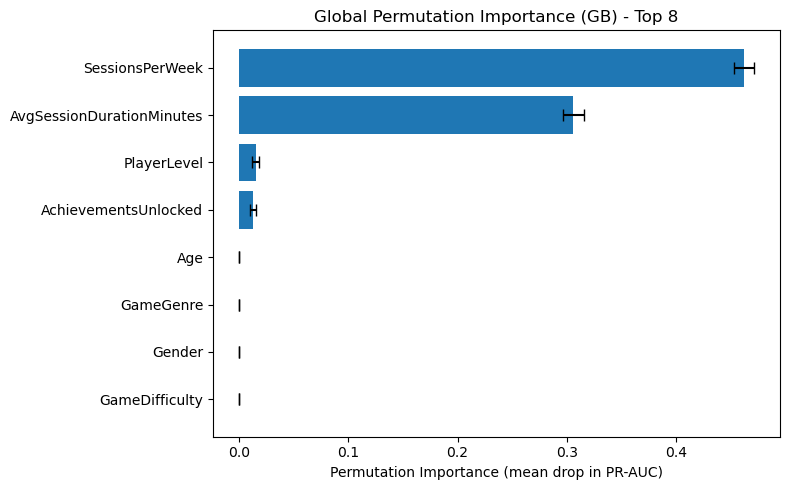

                      feature  importance_mean  importance_std
6             SessionsPerWeek         0.462161        0.009107
7   AvgSessionDurationMinutes         0.305759        0.009392
8                 PlayerLevel         0.015339        0.003158
9        AchievementsUnlocked         0.012895        0.002875
0                         Age         0.000252        0.000135
3                   GameGenre         0.000242        0.000164
1                      Gender        -0.000007        0.000050
4              GameDifficulty        -0.000015        0.000051
10            InGamePurchases        -0.000019        0.000035
2                    Location        -0.000125        0.000154
5               PlayTimeHours        -0.000493        0.000704


In [29]:
# Gradient Boosting Permutation Importance

perm = permutation_importance(
    gb, X_test, y_test, n_repeats=10,
    random_state=42, scoring="average_precision", n_jobs=-1
)
perm_df = pd.DataFrame({
    "feature": X_test.columns.to_numpy(),
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

top_n = 8
top_perm = perm_df.head(top_n).sort_values("importance_mean", ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(top_perm["feature"], top_perm["importance_mean"],
         xerr=top_perm["importance_std"], capsize=4)
plt.xlabel("Permutation Importance (mean drop in PR-AUC)")
plt.title(f"Global Permutation Importance (GB) - Top {top_n}")
plt.tight_layout()
plt.show()
print(perm_df.head(20))

In [30]:
# Error analysis

# Build result table
test_res = X_test.copy()
test_res["y_true"] = y_test.values
test_res["y_pred_gb"] = pred_gb
test_res["proba_gb"] = proba_gb


In [31]:
# False negatives (missed churn-risk)
fn = test_res[(test_res["y_true"] == 1) & (test_res["y_pred_gb"] == 0)]
print(f"False Negatives (missed churn-risk): {fn.shape[0]}")

False Negatives (missed churn-risk): 278


In [32]:
# False positives (over-flagged players)
fp = test_res[(test_res["y_true"] == 0) & (test_res["y_pred_gb"] == 1)]
print(f"False Positives (over-flagged): {fp.shape[0]}")

False Positives (over-flagged): 145


In [33]:
# Segment-level error inspection

# By PlayerLevel
print("\nFN by PlayerLevel quartile:")
print(pd.qcut(fn["PlayerLevel"], 4, duplicates="drop").value_counts())

print("\nFP by PlayerLevel quartile:")
print(pd.qcut(fp["PlayerLevel"], 4, duplicates="drop").value_counts())



FN by PlayerLevel quartile:
PlayerLevel
(0.999, 24.0]    72
(24.0, 49.0]     70
(74.75, 99.0]    70
(49.0, 74.75]    66
Name: count, dtype: int64

FP by PlayerLevel quartile:
PlayerLevel
(0.999, 33.0]    39
(33.0, 56.0]     38
(79.0, 98.0]     36
(56.0, 79.0]     32
Name: count, dtype: int64


In [34]:
# By GameGenre
print("\nFN by GameGenre:")
print(fn["GameGenre"].value_counts().head(10)) 

print("\nFP by GameGenre:")
print(fp["GameGenre"].value_counts().head(10))


FN by GameGenre:
GameGenre
Simulation    68
Action        57
Sports        56
RPG           53
Strategy      44
Name: count, dtype: int64

FP by GameGenre:
GameGenre
Simulation    34
Strategy      32
RPG           32
Action        26
Sports        21
Name: count, dtype: int64


In [35]:
# By payer status
print("\nFN by payer status:")
print(fn.assign(IsPayer=(fn["InGamePurchases"] > 0)).groupby("IsPayer").size())

print("\nFP by payer status:")
print(fp.assign(IsPayer=(fp["InGamePurchases"] > 0)).groupby("IsPayer").size())


FN by payer status:
IsPayer
False    233
True      45
dtype: int64

FP by payer status:
IsPayer
False    108
True      37
dtype: int64


# Overlaid ROC and PR curves

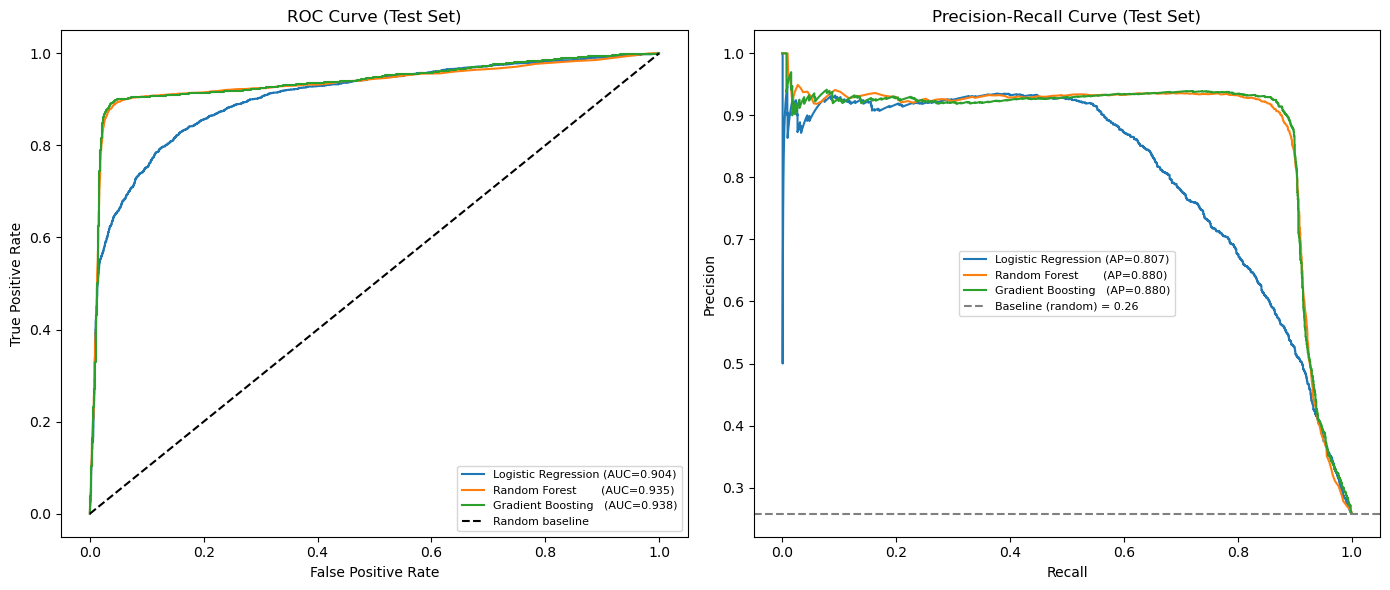

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ROC Curves

for model, proba, label in [
    (log_reg, proba_lr, f"Logistic Regression (AUC={roc_auc_score(y_test, proba_lr):.3f})"),
    (rf, proba_rf,      f"Random Forest       (AUC={roc_auc_score(y_test, proba_rf):.3f})"),
    (gb, proba_gb,      f"Gradient Boosting   (AUC={roc_auc_score(y_test, proba_gb):.3f})"),
]:
    fpr, tpr, _ =roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=label)
axes[0].plot([0,1], [0,1], "k--", label="Random baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (Test Set)")
axes[0].legend(fontsize=8)

# PR Curves

baseline_pr = y_test.mean()
for model, proba, label in [
    (log_reg, proba_lr, f"Logistic Regression (AP={average_precision_score(y_test, proba_lr):.3f})"),
    (rf, proba_rf,      f"Random Forest       (AP={average_precision_score(y_test, proba_rf):.3f})"),
    (gb, proba_gb,      f"Gradient Boosting   (AP={average_precision_score(y_test, proba_gb):.3f})"),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=label)
axes[1].axhline(baseline_pr, linestyle="--", color="grey",
                label=f"Baseline (random) = {baseline_pr:.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (Test Set)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150)
plt.show()